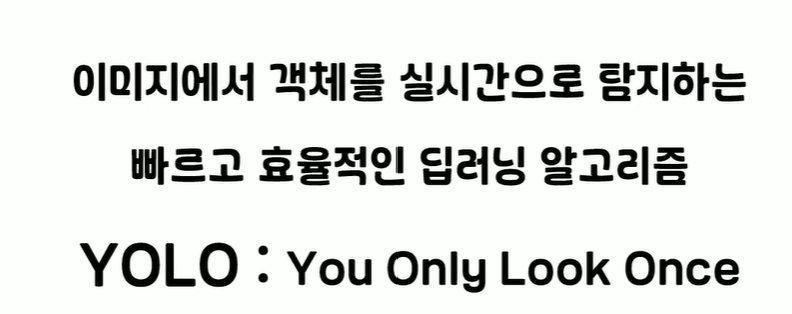

In [ ]:
# 이미지 안의 다양한 오브젝트 분석을 목표로 한다

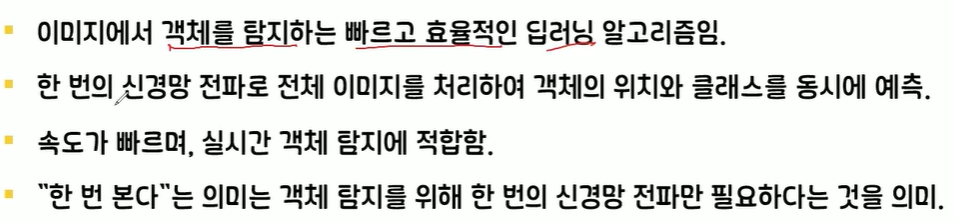

In [ ]:
# 1. 물체가 어디에 있는지 먼저 찾고
# 2. 그 물체가 무엇인지 분류한다
# 기존에 학습되어 있는 물체(오브젝트) 탐지 + 새로운 학습으로 물체(오브젝트) 탐지

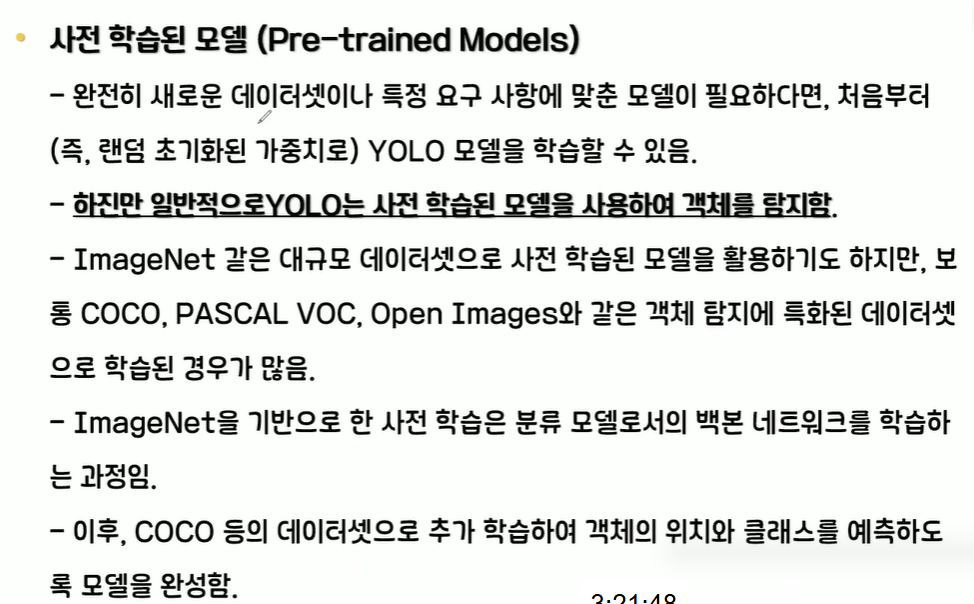

In [ ]:
# YOLO 사용 실습 - Ver.3
# 필요 파일: yolov3.cfg, yolov3.weights, coco.names

0번째 출력층 데이터의 shape: (507, 85)
1번째 출력층 데이터의 shape: (2028, 85)
2번째 출력층 데이터의 shape: (8112, 85)


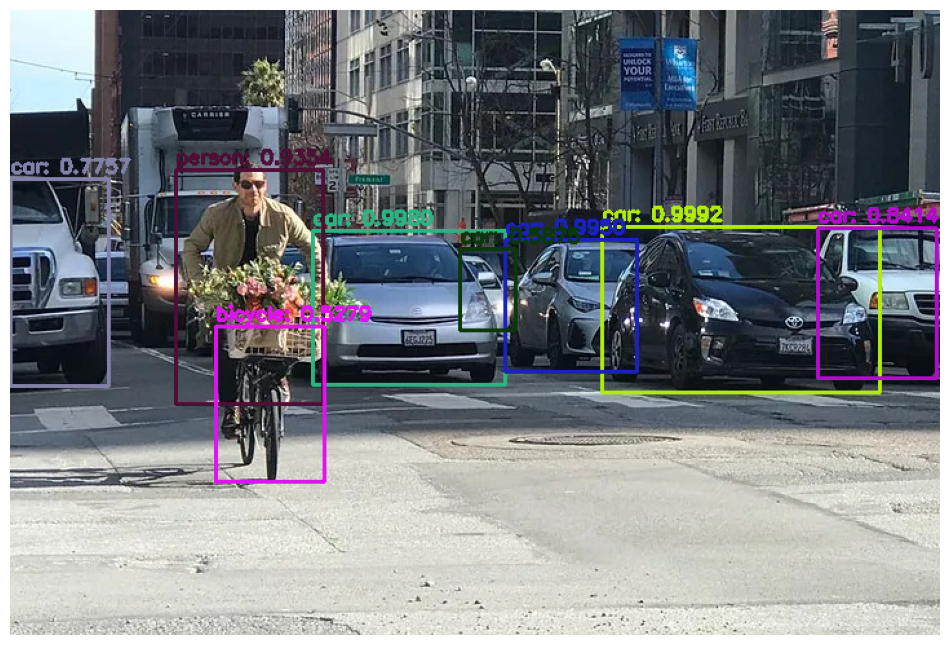

True

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# yolov3.weights: YOLOv3의 사전 학습된 가중치 파일
# yolov3.cfg: YOLOv3모델의 설정 파일
# coco.names: COCO데이터셋의 클래스 이름 파일 경로
weights_path = './yolo/yolov3.weights'
cfg_path = './yolo/yolov3.cfg'
names_path = './yolo/coco.names'

# COCO 데이터셋에서 사용되는 클래스 이름, 파일에서 로드
# f = open(names_path, 'r') + f.close() -> with open(names_path, 'r') as f 
with open(names_path, 'r') as f:
    class_names = f.read().strip().split('\n')

# OpenCV의 DNN모듈 사용, YOLOv3 네트워크를 로드한다
# yolov3.cfg(설정 파일)과 yolov3.weights(가중치 파일)을 사용
# 신경망
net = cv2.dnn.readNetFromDarknet(cfg_path, weights_path)

# 이미지 로드 및 전처리
img_path = './yolo/Yolo_Test_Image.jpg'
img = cv2.imread(img_path) # (세로, 가로, BGR)
# print("img", img.shape)
height, width = img.shape[:2]

# YOLO에 맞게 이미지 전처리
# (416, 416) -> yolov3에서 정한 사이즈, swapRB : BGR -> RGB로 변경
blob = cv2.dnn.blobFromImage(img, 1/255.0, (416, 416), swapRB=True, crop=False)
# print("blob", blob.shape)
## (배치크기, 색상, 세로, 가로)
net.setInput(blob) # 입력층에 blob 배치

# YOLO네트워크에서 출력층을 가져옴
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()] # YOLO는 idx 1번부터 시작 : [i-1]로 0부터 시작하도록 맞춤
outputs = net.forward(output_layers) # 순방향 결과 출력

# 각 출력층별 데이터의 shape 확인 : YOLOv3 -> 출력층 3개, 버전마다 다르다
for i, out in enumerate(outputs):
    print(f"{i}번째 출력층 데이터의 shape: {out.shape}")

# 결과 처리 : YOLO에서 가져온 box 값을, cv2에서 가져온 이미지 파일 크기로 적용하는 과정
boxes = [] # 개체 탐지 박스
confidences = [] # 신뢰도
class_ids = [] # coco.names 클래스번호

for output in outputs:
    for detection in output:
        scores = detection[5:] # detection => [:5] box위치정보, [5:]coco.names에서 가져온 클래스(80개)에 대한 confidences
        class_id = np.argmax(scores)  # scores 배열에서 가장 큰 숫자가 몇번째 방에 있는지 index
        confidence = scores[class_id] # confidence : 가장 높은 확률인 0 ~ 1 사이의 점수  
        if confidence > 0.5:
            box = detection[0:4] * np.array([width, height, width, height]) # 원본 이미지 가로, 세로크기를 곱해준다
            (centerX, centerY, w, h) = box.astype("int")
            x = int(centerX - (w / 2)) # yolo는 center기준, cv2는 좌상단 꼭짓점 기준
            y = int(centerY - (h / 2)) # yolo는 center기준, cv2는 좌상단 꼭짓점 기준
            boxes.append([x, y, int(w), int(h)])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# 비최대 억제 : YOLO가 만든 하나의 사물에 대한 여러 객체탐지 상자 중, 가장 정확한 딱 하나만 남기고 나머지는 제거(억제)
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4) # 0.5 : confidence 0.5 미만 cut, 0.4 : 겹친 면적 0.4 이상이면 낮은 상자 cut

# 탐지된 객체 박스 생성
if len(indices) > 0:
    for i in indices.flatten():
        (x, y) = (boxes[i][0], boxes[i][1])
        (w, h) = (boxes[i][2], boxes[i][3])
        color = [int(c) for c in np.random.randint(0, 255, size=3)]
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        text = "{}: {:.4f}".format(class_names[class_ids[i]], confidences[i])
        cv2.putText(img, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# 결과 이미지 표시
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 결과 이미지 저장
output_img_path = 'output_image.jpg'
cv2.imwrite(output_img_path, img)

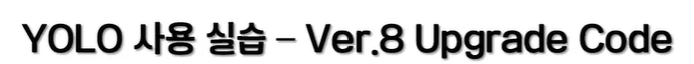

In [ ]:
# !pip install ultralytics

In [3]:
from ultralytics import YOLO

import cv2
import matplotlib.pyplot as plt

# 모델 로드(YOLOv8n - 가장 가벼운 모델)
model = YOLO("yolov8n.pt") # yolov8s.pt, yolov8m.pt 등도 가능

# 이미지 로딩
img_path = "./yolo/Yolo_Test_Image.jpg"

# 추론 모델
results = model(img_path)
# print(results)

# 시각화
results[0].show() # results[0] : 이미지 1장

# 이미지 저장
results[0].save(filename="output_image_v8.jpg")

# 탐지된 객체 출력
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"Class: {model.names[cls]}, Confidence: {conf:.4f}")


image 1/1 C:\Users\wodnr7301\notebooks\0529\yolo\Yolo_Test_Image.jpg: 448x640 1 person, 1 bicycle, 9 cars, 108.0ms
Speed: 2.8ms preprocess, 108.0ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Class: car, Confidence: 0.8970
Class: car, Confidence: 0.8728
Class: car, Confidence: 0.8548
Class: person, Confidence: 0.8442
Class: car, Confidence: 0.7608
Class: car, Confidence: 0.7351
Class: bicycle, Confidence: 0.6919
Class: car, Confidence: 0.4523
Class: car, Confidence: 0.3680
Class: car, Confidence: 0.2802
Class: car, Confidence: 0.2503
